# NSW Housing Market Analysis & Development Recommendation

**Python Data Analysis Portfolio**

This notebook independently rebuilds the analytical workflow for a NSW housing dataset covering **Kellyville, Blacktown and Castle Hill (2021–2023)**.

### Business objective
Compare the three suburbs and identify patterns in affordability, price stability and property characteristics that can support an initial **mid-market residential development screening**.

### Python workflow
1. Load and validate the cleaned dataset  
2. Check missing values, duplicates and data types  
3. Inspect potential outliers  
4. Produce descriptive statistics and coefficient of variation  
5. Compare suburbs and price trends  
6. Analyse price distributions and relationships  
7. Merge macroeconomic indicators  
8. Run a multiple linear regression for Blacktown  
9. Summarise analytical findings and limitations  

> The dataset originated from a course project. The Python analysis in this notebook is presented as an independently rebuilt portfolio workflow.

## 1. Setup

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

## 2. Load the cleaned housing dataset

In [2]:
# Portable file paths for GitHub/local use
data_candidates = [
    Path("../data/NSW_Housing_PowerBI.xlsx"),
    Path("data/NSW_Housing_PowerBI.xlsx"),
    Path("NSW_Housing_PowerBI.xlsx"),
]

DATA_PATH = next((p for p in data_candidates if p.exists()), None)

if DATA_PATH is None:
    raise FileNotFoundError(
        "NSW_Housing_PowerBI.xlsx was not found. "
        "Place it in the repository data/ folder or beside this notebook."
    )

df = pd.read_excel(DATA_PATH, sheet_name="Sheet1")
df.head()

,sold_date,suburb,year,sold_price,land_size,rooms
0,2021-06-15,Kellyville,2021,1340000,450.00,5
1,2021-05-29,Kellyville,2021,1255000,450.00,4
2,2021-03-28,Kellyville,2021,1425000,453.00,4
3,2021-04-19,Kellyville,2021,1500000,525.00,5
4,2021-02-27,Kellyville,2021,1325000,525.00,4


In [3]:
print("Dataset shape:", df.shape)
print("\nColumns:", list(df.columns))
print("\nData types:")
print(df.dtypes)

Dataset shape: (270, 6)

Columns: ['sold_date', 'suburb', 'year', 'sold_price', 'land_size', 'rooms']

Data types:
sold_date     datetime64[ns]
suburb                object
year                   int64
sold_price             int64
land_size            float64
rooms                  int64
dtype: object


## 3. Data quality checks

The dataset is checked before analysis. Suspicious records are not automatically changed unless there is clear evidence that they are data-entry errors.

In [4]:
quality_summary = pd.DataFrame({
    "missing_values": df.isna().sum(),
    "data_type": df.dtypes.astype(str)
})

print("Duplicate rows:", df.duplicated().sum())
quality_summary

Duplicate rows: 0


,missing_values,data_type
sold_date,0,datetime64[ns]
suburb,0,object
year,0,int64
sold_price,0,int64
land_size,0,float64
rooms,0,int64


In [5]:
# Standardise data types explicitly
df["sold_date"] = pd.to_datetime(df["sold_date"], errors="coerce")
df["year"] = pd.to_numeric(df["year"], errors="coerce")
df["sold_price"] = pd.to_numeric(df["sold_price"], errors="coerce")
df["land_size"] = pd.to_numeric(df["land_size"], errors="coerce")
df["rooms"] = pd.to_numeric(df["rooms"], errors="coerce")

invalid_numeric = df[
    (df["sold_price"] <= 0) |
    (df["land_size"] <= 0) |
    (df["rooms"] <= 0)
]

date_year_mismatch = df[
    df["sold_date"].notna() &
    (df["sold_date"].dt.year != df["year"])
]

print("Invalid numeric rows:", len(invalid_numeric))
print("Date/year mismatches:", len(date_year_mismatch))

Invalid numeric rows: 0
Date/year mismatches: 1


## 4. Outlier inspection

Potential outliers are **flagged rather than automatically deleted**. In property data, a large sale price or land parcel may represent a genuine property rather than an error.

In [6]:
def iqr_outliers(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = (series < lower) | (series > upper)
    return lower, upper, mask

price_lower, price_upper, price_mask = iqr_outliers(df["sold_price"])
land_lower, land_upper, land_mask = iqr_outliers(df["land_size"])

print(f"Price IQR bounds: {price_lower:,.0f} to {price_upper:,.0f}")
print("Potential price outliers:", int(price_mask.sum()))
print(f"Land-size IQR bounds: {land_lower:,.2f} to {land_upper:,.2f}")
print("Potential land-size outliers:", int(land_mask.sum()))

Price IQR bounds: -205,000 to 3,009,000
Potential price outliers: 5
Land-size IQR bounds: 61.25 to 1,153.25
Potential land-size outliers: 10


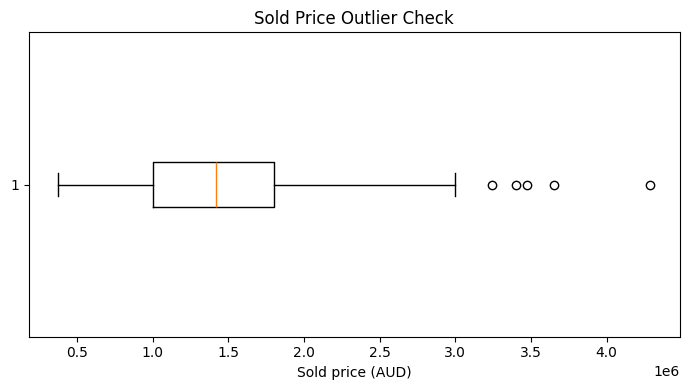

In [7]:
plt.figure(figsize=(7, 4))
plt.boxplot(df["sold_price"].dropna(), vert=False)
plt.xlabel("Sold price (AUD)")
plt.title("Sold Price Outlier Check")
plt.tight_layout()
plt.show()

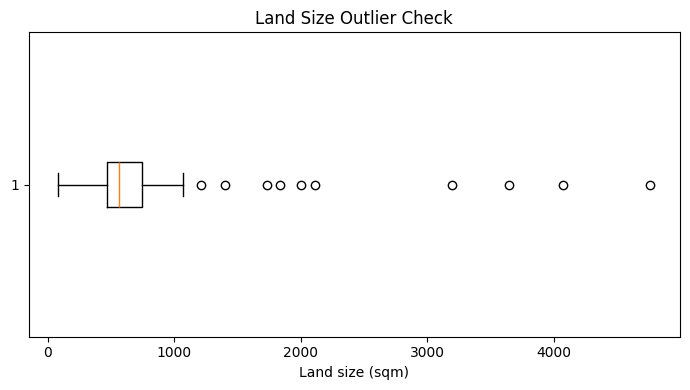

In [8]:
plt.figure(figsize=(7, 4))
plt.boxplot(df["land_size"].dropna(), vert=False)
plt.xlabel("Land size (sqm)")
plt.title("Land Size Outlier Check")
plt.tight_layout()
plt.show()

## 5. Descriptive statistics and market stability

In [9]:
df[["sold_price", "land_size", "rooms"]].describe().T

,count,mean,std,min,25%,50%,75%,max
sold_price,270.00,"1,497,937.76","615,774.96","375,000.00","1,000,250.00","1,420,000.00","1,803,750.00","4,289,000.00"
land_size,270.00,677.17,479.66,81.00,470.75,563.00,743.75,"4,764.00"
rooms,270.00,4.06,0.95,1.00,3.00,4.00,5.00,6.00


In [10]:
price_stats = (
    df.groupby(["suburb", "year"])["sold_price"]
      .agg(
          sample_count="count",
          mean_price="mean",
          median_price="median",
          std_price="std"
      )
)

price_stats["cv"] = price_stats["std_price"] / price_stats["mean_price"]
price_stats

sample_count   mean_price  median_price  std_price   cv
suburb      year                                                         
Blacktown   2021            30   966,383.33    923,000.00 188,569.28 0.20
            2022            30   960,858.33    965,000.00 175,808.65 0.18
            2023            30   962,251.83    909,250.00 176,007.93 0.18
Castle Hill 2021            30 1,856,519.60  1,737,444.00 488,468.74 0.26
            2022            30 2,354,483.33  2,075,000.00 629,867.18 0.27
            2023            30 2,105,866.70  2,020,000.50 468,994.79 0.22
Kellyville  2021            30 1,165,966.67  1,215,500.00 285,900.54 0.25
            2022            30 1,609,950.00  1,587,500.00 304,288.67 0.19
            2023            30 1,499,160.00  1,505,000.00 318,281.02 0.21

In [11]:
price_stats.reset_index().sort_values(["year", "cv"])[
    ["suburb", "year", "mean_price", "median_price", "cv"]
]

,suburb,year,mean_price,median_price,cv
0,Blacktown,2021,"966,383.33","923,000.00",0.20
6,Kellyville,2021,"1,165,966.67","1,215,500.00",0.25
3,Castle Hill,2021,"1,856,519.60","1,737,444.00",0.26
1,Blacktown,2022,"960,858.33","965,000.00",0.18
7,Kellyville,2022,"1,609,950.00","1,587,500.00",0.19
4,Castle Hill,2022,"2,354,483.33","2,075,000.00",0.27
2,Blacktown,2023,"962,251.83","909,250.00",0.18
8,Kellyville,2023,"1,499,160.00","1,505,000.00",0.21
5,Castle Hill,2023,"2,105,866.70","2,020,000.50",0.22


**Interpretation:** A lower coefficient of variation (CV) indicates stronger relative price stability after accounting for differences in average price levels.

## 6. Price trend and cross-suburb comparison

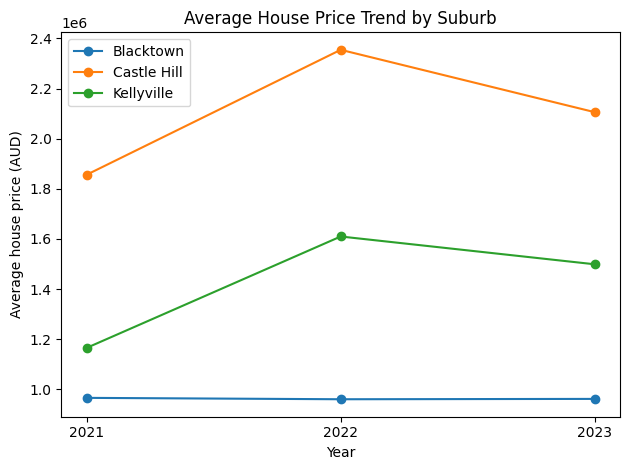

In [12]:
trend = (
    df.groupby(["year", "suburb"])["sold_price"]
      .mean()
      .reset_index()
)

for suburb in trend["suburb"].unique():
    temp = trend[trend["suburb"] == suburb]
    plt.plot(temp["year"], temp["sold_price"], marker="o", label=suburb)

plt.xticks([2021, 2022, 2023])
plt.xlabel("Year")
plt.ylabel("Average house price (AUD)")
plt.title("Average House Price Trend by Suburb")
plt.legend()
plt.tight_layout()
plt.show()

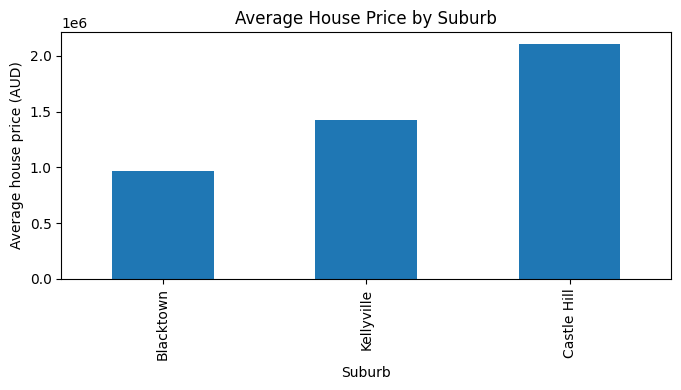

In [13]:
suburb_avg = (
    df.groupby("suburb")["sold_price"]
      .mean()
      .sort_values()
)

plt.figure(figsize=(7, 4))
suburb_avg.plot(kind="bar")
plt.xlabel("Suburb")
plt.ylabel("Average house price (AUD)")
plt.title("Average House Price by Suburb")
plt.tight_layout()
plt.show()

## 7. House-price distribution

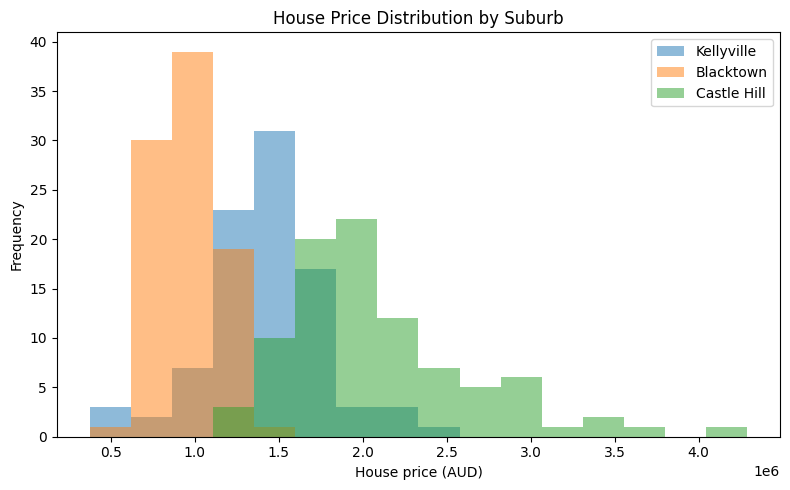

In [14]:
bins = np.histogram_bin_edges(df["sold_price"], bins="fd")

plt.figure(figsize=(8, 5))
for suburb in df["suburb"].unique():
    temp = df[df["suburb"] == suburb]
    temp["sold_price"].plot(
        kind="hist",
        bins=bins,
        alpha=0.5,
        label=suburb
    )

plt.xlabel("House price (AUD)")
plt.ylabel("Frequency")
plt.title("House Price Distribution by Suburb")
plt.legend()
plt.tight_layout()
plt.show()

## 8. Property characteristics and correlation

In [15]:
correlation = df[["sold_price", "land_size", "rooms"]].corr()
correlation

,sold_price,land_size,rooms
sold_price,1.00,0.25,0.42
land_size,0.25,1.00,-0.04
rooms,0.42,-0.04,1.00


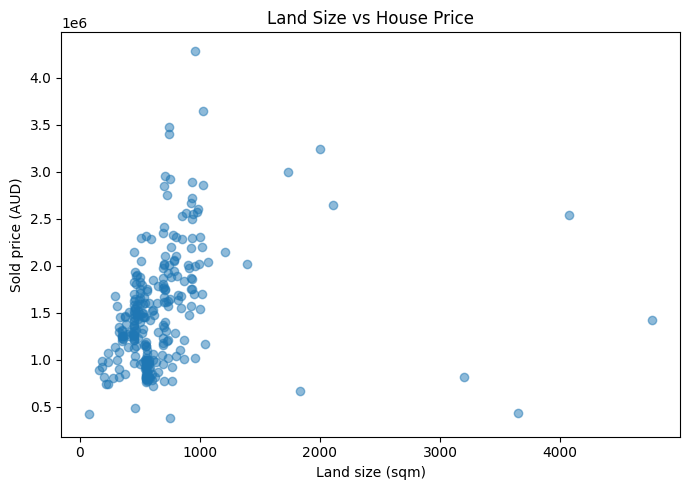

In [16]:
plt.figure(figsize=(7, 5))
plt.scatter(df["land_size"], df["sold_price"], alpha=0.5)
plt.xlabel("Land size (sqm)")
plt.ylabel("Sold price (AUD)")
plt.title("Land Size vs House Price")
plt.tight_layout()
plt.show()

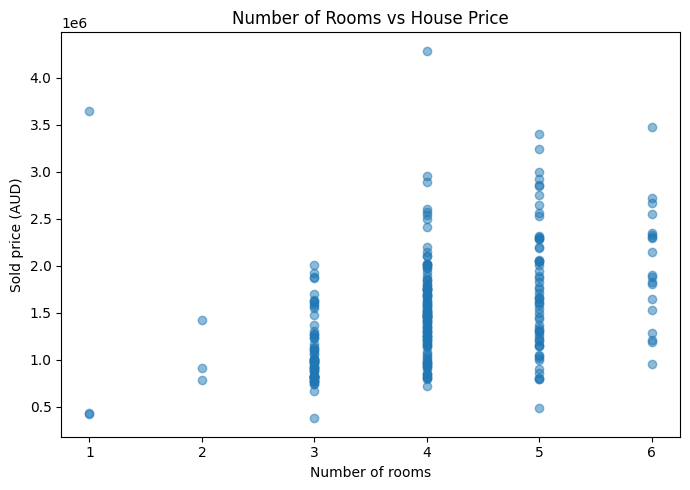

In [17]:
plt.figure(figsize=(7, 5))
plt.scatter(df["rooms"], df["sold_price"], alpha=0.5)
plt.xlabel("Number of rooms")
plt.ylabel("Sold price (AUD)")
plt.title("Number of Rooms vs House Price")
plt.tight_layout()
plt.show()

## 9. Macroeconomic data merge

In [18]:
economic_data = pd.DataFrame({
    "year": [2021, 2022, 2023],
    "cash_rate": [0.10, 3.10, 4.35],
    "inflation": [3.50, 7.80, 4.10],
    "unemployment": [4.20, 3.50, 3.90]
})

merged_df = pd.merge(
    df,
    economic_data,
    on="year",
    how="left"
)

merged_df[[
    "year", "cash_rate", "inflation", "unemployment"
]].drop_duplicates().sort_values("year")

,year,cash_rate,inflation,unemployment
0,2021,0.10,3.50,4.20
30,2022,3.10,7.80,3.50
60,2023,4.35,4.10,3.90


The merge demonstrates multi-table integration. These macro variables vary only by year, so they are treated as contextual indicators rather than strong causal predictors in this small dataset.

## 10. Multiple linear regression — Blacktown

In [19]:
blacktown = df[df["suburb"] == "Blacktown"].copy()

# Convert explicitly to float for statsmodels compatibility
X = blacktown[["land_size", "rooms"]].astype(float)
X = sm.add_constant(X)
y = blacktown["sold_price"].astype(float)

model_blacktown = sm.OLS(y, X).fit()
model_blacktown.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             sold_price   R-squared:                       0.261
Model:                            OLS   Adj. R-squared:                  0.244
Method:                 Least Squares   F-statistic:                     15.40
Date:                Tue, 25 Aug 2026   Prob (F-statistic):           1.89e-06
Time:                        08:39:30   Log-Likelihood:                -1201.7
No. Observations:                  90   AIC:                             2409.
Df Residuals:                      87   BIC:                             2417.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       6.315e+05   7.28e+04      8.673      0.000    4.87e+05    7.76e+05
land_size    -44.2808     48.801     -0.907      0.367    -141.278      52.716
rooms       9.486e+04   1.72e+04      5.506      0.000    6.06e+04    1.29e+05
==============================================================================
Omnibus:                        1.929   Durbin-Watson:                   2.271
Prob(Omnibus):                  0.381   Jarque-Bera (JB):                1.324
Skew:                          -0.178   Prob(JB):                        0.516
Kurtosis:                       3.475   Cond. No.                     3.24e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.24e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [20]:
regression_results = pd.DataFrame({
    "coefficient": model_blacktown.params,
    "p_value": model_blacktown.pvalues
})

print("Adjusted R-squared:", round(model_blacktown.rsquared_adj, 4))
regression_results

Adjusted R-squared: 0.2444


,coefficient,p_value
const,"631,520.60",0.00
land_size,-44.28,0.37
rooms,"94,857.29",0.00


### Regression interpretation

For the Blacktown sample:

- The model explains approximately **24.4%** of observed price variation after adjustment.
- Holding land size constant, one additional room is associated with roughly **AUD 95,000** higher sale price.
- The room-count coefficient is statistically significant, while marginal land size is not statistically significant after controlling for rooms.
- This is an **association**, not proof that adding a room mechanically causes a fixed increase in price.

## 11. Key analytical findings

1. **Blacktown combines lower prices with stronger relative price stability**, making it the strongest initial candidate for a mid-market development screening.
2. **Castle Hill is consistently the premium-priced market**, implying a substantially higher entry cost.
3. **Kellyville experienced strong growth from 2021 to 2022 followed by a decline in 2023**, indicating stronger growth potential but less stable short-term movement.
4. **Room count is a more reliable price-related variable than marginal land size in the Blacktown regression.**
5. **Large land parcels distort average land-size statistics**, so medians and distributions should be considered alongside means.

### Limitations
- The dataset contains 270 observations and is not a complete market census.
- Large land parcels are retained because they may be genuine properties.
- Regression results describe association, not causation.
- The macroeconomic variables contain only three annual values, limiting statistical inference.
- The analysis should be treated as an initial screening exercise rather than a final investment decision.